<a href="https://colab.research.google.com/github/abrarhossam51-max/Phantoms-W3-Ai/blob/main/W3D5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

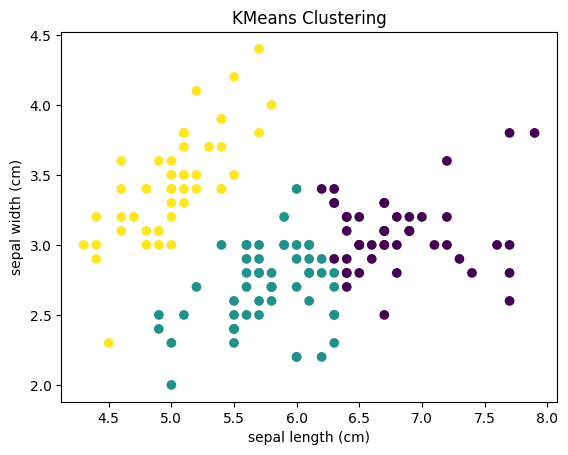

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

data = load_iris()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

X_2d = X.iloc[:, [0, 1]]

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_2d)

plt.scatter(
    X_2d.iloc[:, 0],
    X_2d.iloc[:, 1],
    c=clusters
)

plt.xlabel(data.feature_names[0])
plt.ylabel(data.feature_names[1])
plt.title("KMeans Clustering")

plt.show()

In [2]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

data = load_iris()

df = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

df["target"] = data.target

# Data Leakage: this feature is copied from the label
df["target_copy"] = df["target"]

X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy with Data Leakage:", accuracy)

# Data Leakage happens when information from the label
# is included in the features.
# This makes the model see information it should not have
# during prediction and produces unrealistically high accuracy.

# Fix the problem by removing the leaked feature
X = df.drop(columns=["target", "target_copy"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

fixed_accuracy = accuracy_score(y_test, y_pred)

print("Accuracy after fixing Data Leakage:", fixed_accuracy)

Accuracy with Data Leakage: 1.0
Accuracy after fixing Data Leakage: 1.0


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Load dataset
df = pd.read_csv("cleaned_data.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())


X = df.drop(columns=["Survived"])
y = df["Survived"]

print("\nFeatures:")
print(X.columns)
print("\nLabel:")
print(y.name)


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train, y_train)

logistic_pred = logistic_model.predict(X_test)
logistic_accuracy = accuracy_score(y_test, logistic_pred)

tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)
tree_accuracy = accuracy_score(y_test, tree_pred)

knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)
knn_accuracy = accuracy_score(y_test, knn_pred)

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "KNN"
    ],
    "Accuracy": [
        logistic_accuracy,
        tree_accuracy,
        knn_accuracy
    ]
})

print("\nModel Comparison:")
print(results)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_scaled_model = KNeighborsClassifier()

knn_scaled_model.fit(X_train_scaled, y_train)

knn_scaled_pred = knn_scaled_model.predict(X_test_scaled)

knn_scaled_accuracy = accuracy_score(
    y_test,
    knn_scaled_pred
)

print("\nKNN before scaling:", knn_accuracy)
print("KNN after scaling:", knn_scaled_accuracy)